# Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
nltk.download('stopwords')
from nltk.stem.porter import PorterStemmer
import string
import re

from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC

from sklearn.ensemble import StackingClassifier, VotingClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from sklearn.model_selection import RandomizedSearchCV

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sahil\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\sahil\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sahil\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Loading Dataset and checking basic structure

In [4]:
df = pd.read_csv('twitter_sentiment.csv')

In [5]:
df.shape

(75681, 4)

In [6]:
df.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [7]:
df = df.iloc[:, [2, 3]].reset_index(drop=True)
df.columns = ['sentiment', 'text']

In [8]:
df.head()

,sentiment,text
0,Positive,I am coming to the borders and I will kill you...
1,Positive,im getting on borderlands and i will kill you ...
2,Positive,im coming on borderlands and i will murder you...
3,Positive,im getting on borderlands 2 and i will murder ...
4,Positive,im getting into borderlands and i can murder y...


In [9]:
df['sentiment'].isna().sum()

0

In [10]:
df['text'].isna().sum()

686

In [11]:
df.dropna(inplace=True)

df = df[df['text'].apply(len)>1]

In [12]:
df['sentiment'].value_counts()

Negative      22530
Positive      20843
Neutral       18285
Irrelevant    12988
Name: sentiment, dtype: int64

In [13]:
# checking for duplicate instances
no_of_duplicates=df.duplicated().sum()
no_of_duplicates

4430

In [14]:
df.drop_duplicates(inplace=True)

In [15]:
df.shape

(70216, 2)

In [16]:
df['sentiment'].value_counts()

Negative      21320
Positive      19262
Neutral       17270
Irrelevant    12364
Name: sentiment, dtype: int64

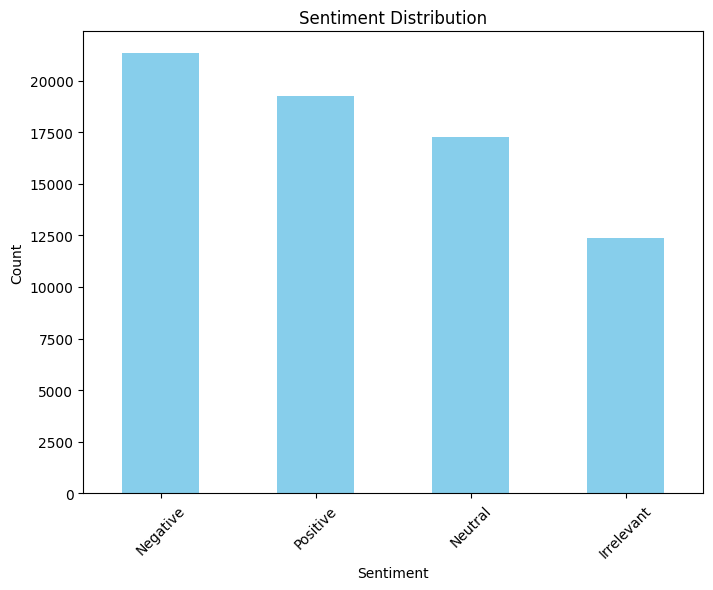

In [17]:
sentiment_counts = df['sentiment'].value_counts()

plt.figure(figsize=(8, 6))
sentiment_counts.plot(kind='bar', color='skyblue')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

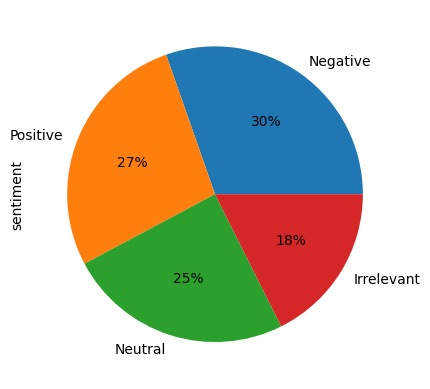

In [18]:
df['sentiment'].value_counts().plot(kind='pie', autopct='%1.0f%%')
plt.show()

# Finding and Visualizing No. of characters, words, sentences in each movie review group by their sentiments.

In [20]:
df['txt_characters'] = df['text'].apply(len)
df['txt_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))
df['txt_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [21]:
df.head()

,sentiment,text,txt_characters,txt_words,txt_sentences
0,Positive,I am coming to the borders and I will kill you...,51,13,1
1,Positive,im getting on borderlands and i will kill you ...,50,11,1
2,Positive,im coming on borderlands and i will murder you...,51,11,1
3,Positive,im getting on borderlands 2 and i will murder ...,57,13,1
4,Positive,im getting into borderlands and i can murder y...,53,11,1


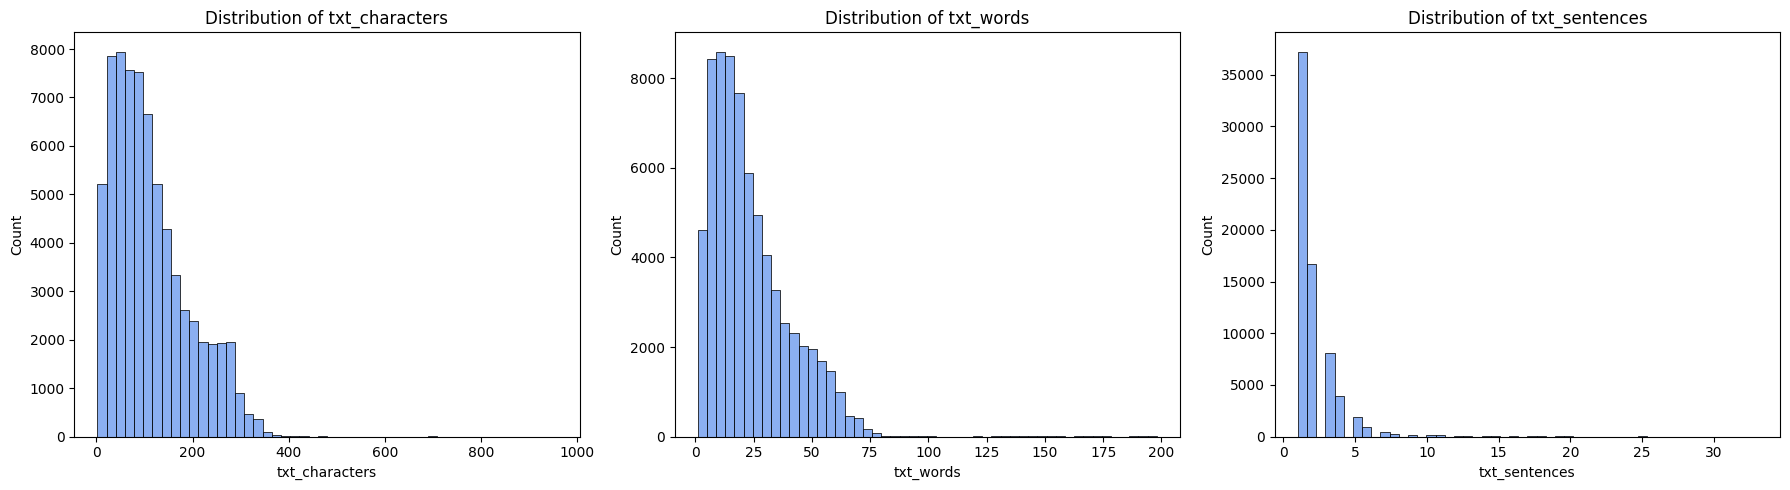

In [22]:
numerical_feature_cols=['txt_characters', 'txt_words', 'txt_sentences']
plt.figure(figsize=(18, 5))
for i,col in enumerate(numerical_feature_cols):
    plt.subplot(1,3,i+1)
    sns.histplot(data=df,x=col,bins=50,color='#6495ED')
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

# We can conclude that the dataset is right skewed and contains outliers too from above Histogram Graph.

In [24]:
df[['txt_characters', 'txt_words', 'txt_sentences']].describe()

,txt_characters,txt_words,txt_sentences
count,70216.000000,70216.000000,70216.000000
mean,112.898898,23.421457,1.983622
std,78.587553,16.987672,1.648199
min,2.000000,1.000000,1.000000
25%,51.000000,11.000000,1.000000
50%,95.000000,19.000000,1.000000
75%,157.000000,32.000000,2.000000
max,957.000000,198.000000,33.000000


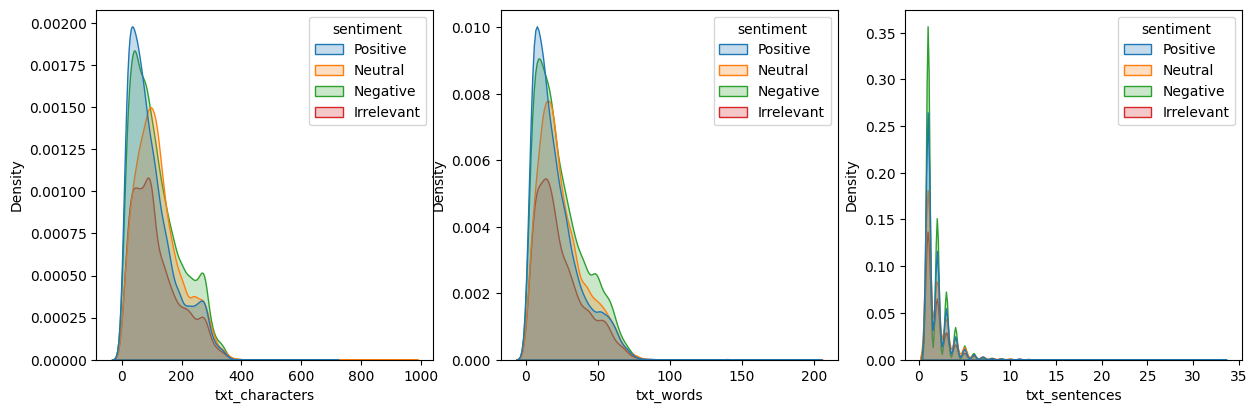

In [25]:
plt.figure(figsize=(20,10))

num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    plt.subplot(2,4, num_cols.get_loc(col)+1)
    sns.kdeplot(data=df, x=col, hue='sentiment', fill=True)

# Moview Review before processing text using nltk

In [27]:
print(df['text'][100])
print(df['sentiment'][100])

Grounded almost was pretty cool even despite the top tier unfunny writing until we became yet another annoying crafting game. I seriously can’t wait on this shitty trend to die
Negative


# Data Preprocessing

In [29]:
stopwords_set = set(stopwords.words('english'))

def transform_text(text):
    # Remove retweet markers (RT)
    text = re.sub(r'\bRT\b', '', text)

    # Remove URLs (http, https, www)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<[^>]*>', '', text)

    # Remove emojis
    text = re.sub(r'(?::|;|=)(?:-)?(?:\)|\(|D|P)', '', text)

    # Replace non-word characters (punctuation) with spaces and convert text to lowercase
    text = re.sub(r'[\W+]', ' ', text.lower())

    # Tokenize the text using nltk.word_tokenize for proper tokenization
    tokens = nltk.word_tokenize(text)

    # Initialize the stemmer
    prter = PorterStemmer()

    # Stem tokens and remove stopwords
    text = [prter.stem(word) for word in tokens if word not in stopwords_set]

    # Remove extra spaces and join the words back
    return " ".join(text)

In [30]:
df['transformed_text'] = df['text'].apply(transform_text)

# Sample test of transfrom_text function

In [32]:
transform_text('RT Check this out! 😃 <p>Visit our website at https://www.example.com for amazing deals!!!</p> 🎉 #Sale #Discount')

'check visit websit amaz deal sale discount'

# Moview Review After processing text using nltk

In [34]:
print(df['transformed_text'][100])
print(df['sentiment'][100])

ground almost pretti cool even despit top tier unfunni write becam yet anoth annoy craft game serious wait shitti trend die
Negative


# Visualizing WordCloud

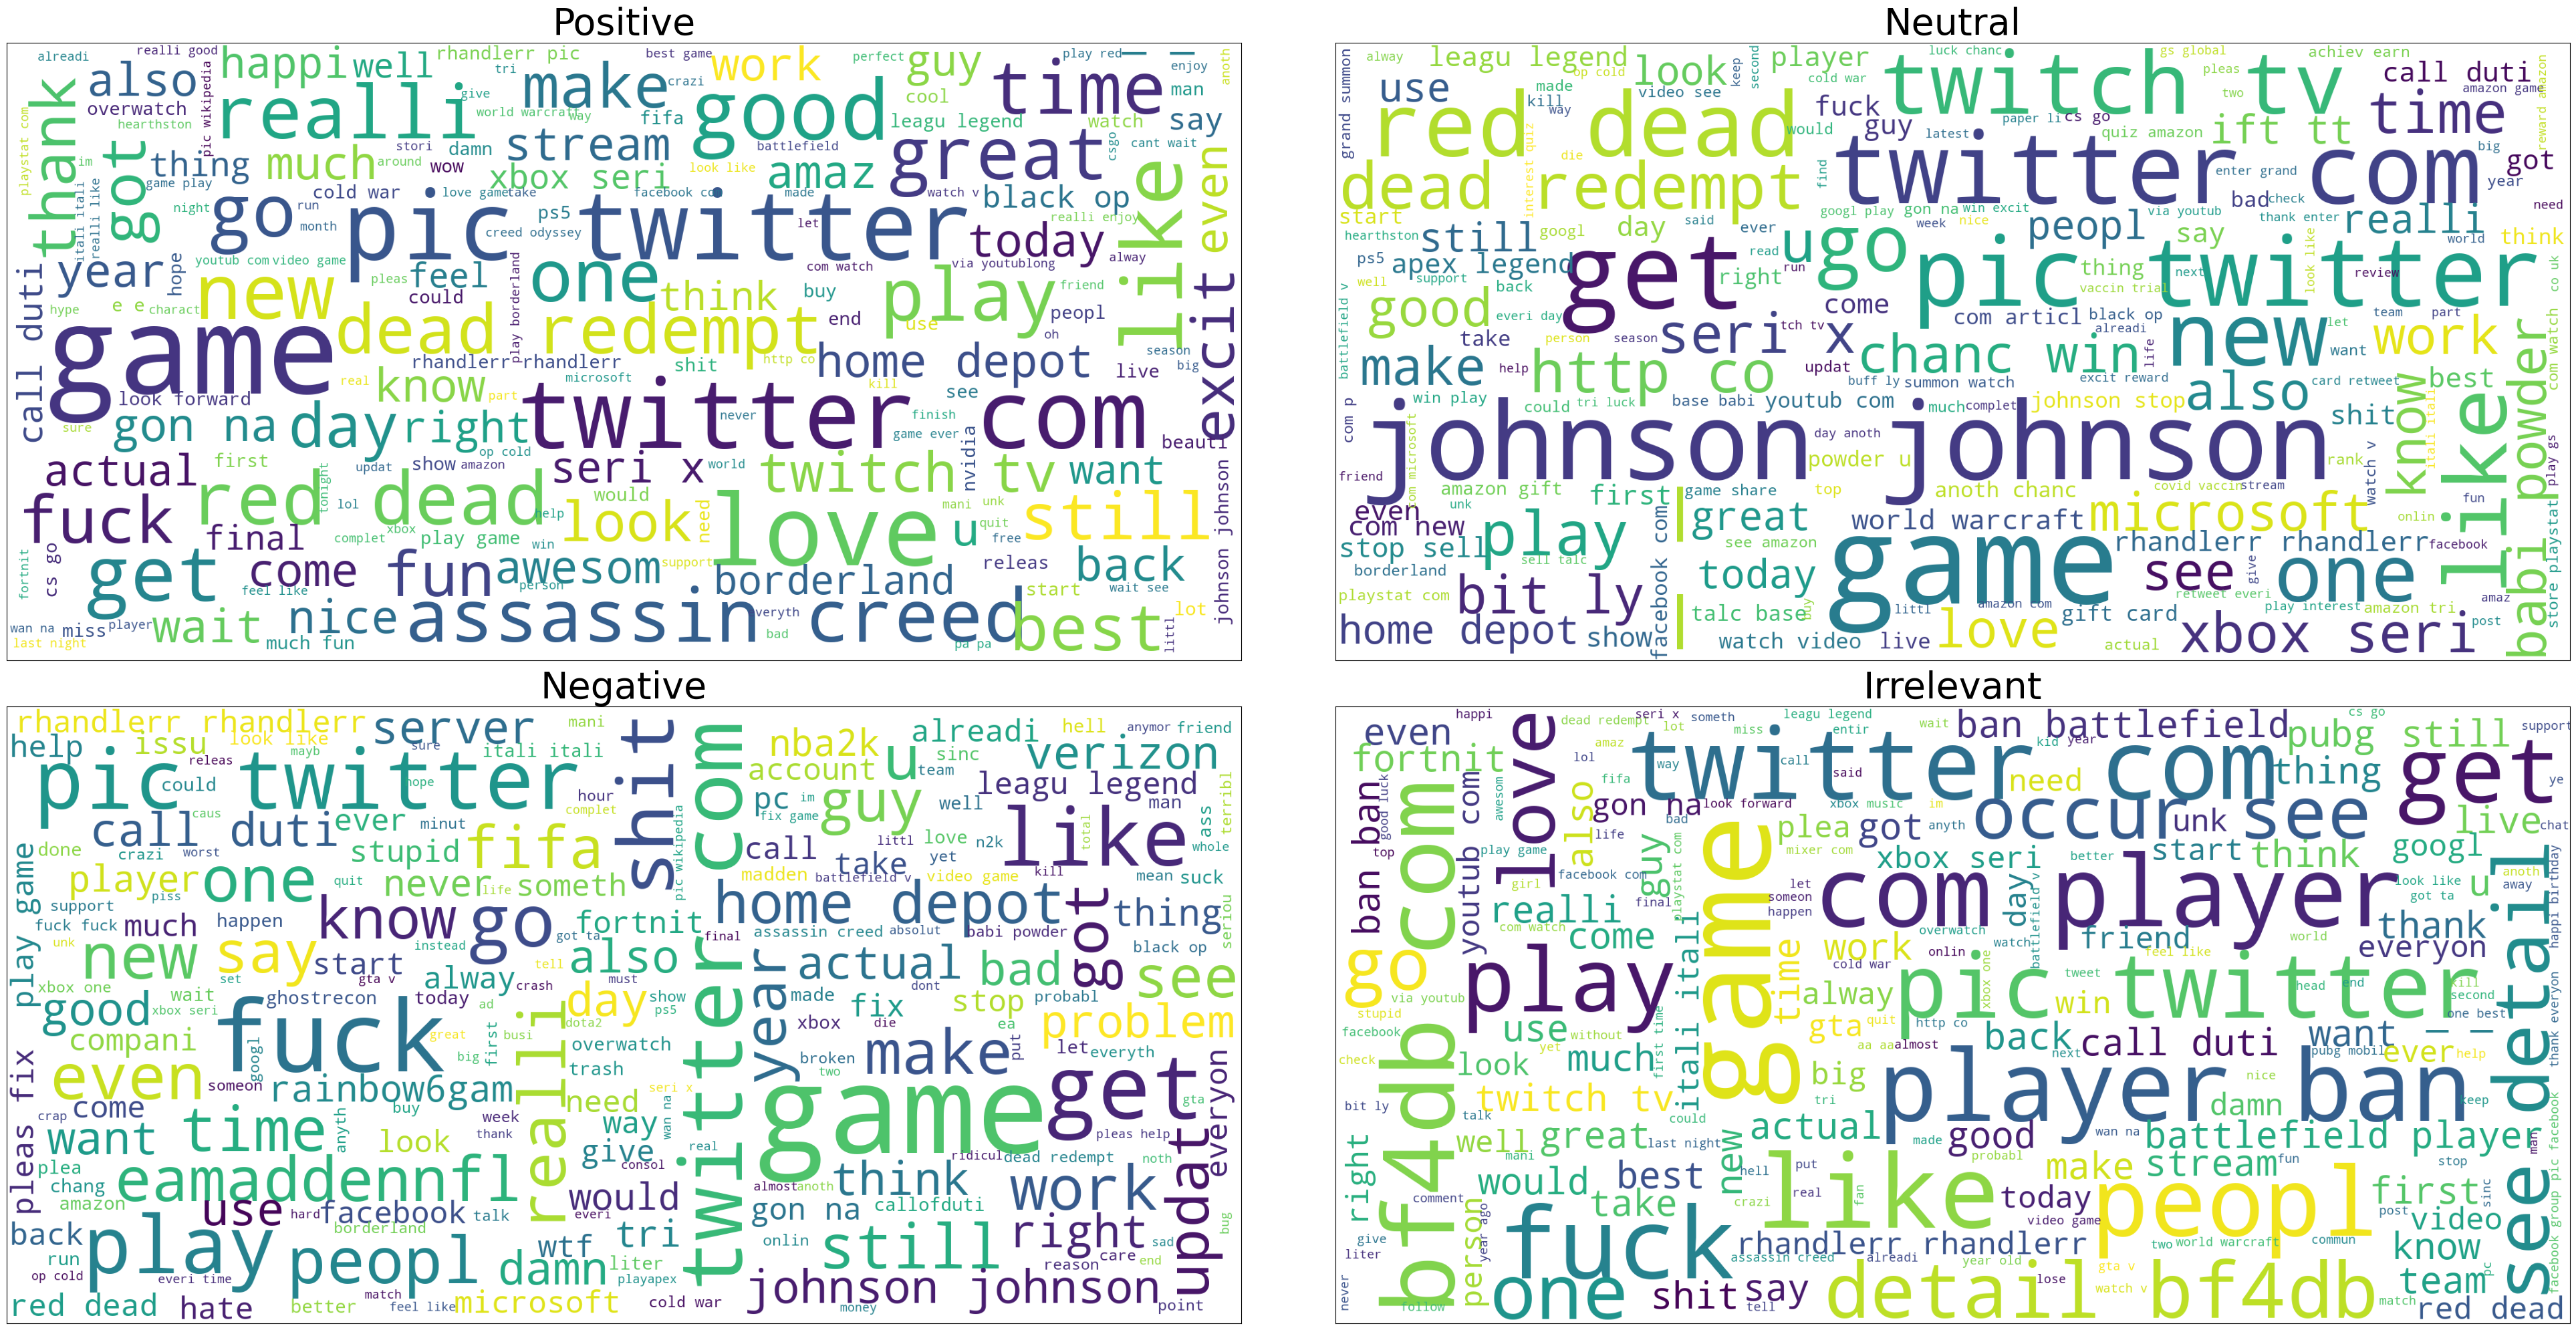

In [36]:
stopwords_set = set(stopwords.words('english'))

plt.figure(figsize=(40, 20))

for index, col in enumerate(df['sentiment'].unique()):
    plt.subplot(2, 2, index + 1)
    df1 = df[df['sentiment'] == col]
    data = df1['transformed_text']
    wordcloud = WordCloud(
        background_color='white',
        stopwords=stopwords_set,
        max_words=500,
        max_font_size=40,
        scale=5
    ).generate(' '.join(data))

    plt.xticks([])
    plt.yticks([])
    plt.imshow(wordcloud)
    plt.title(col, fontsize=40)

plt.tight_layout()
plt.show()

# Data Processing

In [38]:
tfidf = TfidfVectorizer(max_features = 5000)
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [39]:
X.shape

(70216, 5000)

# Encoding Sentiments

In [41]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(df['sentiment'])

for index, label in enumerate(label_encoder.classes_):
    print(f"{label}: {index}")

Irrelevant: 0
Negative: 1
Neutral: 2
Positive: 3


# Train-Test Split

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# All models object that will be used for tweets classification

In [45]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()
svc = LinearSVC()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=100, random_state=2, n_jobs=-1)
abc = AdaBoostClassifier(n_estimators=20, learning_rate = 0.5, random_state=2)
etc = ExtraTreesClassifier(n_estimators=100, random_state=2, n_jobs=-1)
xgb = XGBClassifier(n_estimators=30, max_depth=3, gamma=1, subsample=0.8, colsample_bytree=0.8, random_state=2, n_jobs=-1)

# Classifier model dictionary and function to get accuracy and precision across all models

In [47]:
clfs = {
    'GNB': gnb,
    'MNB': mnb,
    'BNB' : bnb,
    'SVC': svc,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'ETC': etc,
    'xgb':xgb,
}

In [48]:
def train_classifier(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    # Calculate accuracy and precision
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')

    return accuracy, precision

# store results
accuracy = []
precision = []

In [37]:
for name, clf in clfs.items():
    print(f"Training and evaluating model: {name}...")

    current_accuracy, current_precision = train_classifier(clf, X_train, y_train, X_test, y_test)

    # Append results to lists
    accuracy.append(current_accuracy)
    precision.append(current_precision)

    # Print results
    print(f"{name} -> Accuracy: {current_accuracy:.2f}, Precision: {current_precision:.2f}\n")

Training and evaluating model: GNB...
GNB -> Accuracy: 0.46, Precision: 0.60

Training and evaluating model: MNB...
MNB -> Accuracy: 0.65, Precision: 0.67

Training and evaluating model: BNB...
BNB -> Accuracy: 0.64, Precision: 0.65

Training and evaluating model: SVC...
SVC -> Accuracy: 0.72, Precision: 0.72

Training and evaluating model: DT...
DT -> Accuracy: 0.37, Precision: 0.61

Training and evaluating model: LR...
LR -> Accuracy: 0.69, Precision: 0.69

Training and evaluating model: RF...
RF -> Accuracy: 0.91, Precision: 0.91

Training and evaluating model: AdaBoost...


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


AdaBoost -> Accuracy: 0.34, Precision: 0.44

Training and evaluating model: ETC...
ETC -> Accuracy: 0.93, Precision: 0.93

Training and evaluating model: xgb...
xgb -> Accuracy: 0.52, Precision: 0.58



# Checking performance across all models

In [65]:
#accuracy = [0.456067, 0.652093, 0.643406, 0.724722, 0.365708, 0.687625, 0.907434, 0.337297, 0.926873, 0.517659]
#precision = [0.604181, 0.668734, 0.648468, 0.722012, 0.613872, 0.685022, 0.913089, 0.443791, 0.930660, 0.581763]

performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy,'Precision':precision}).sort_values('Precision',ascending=False)

performance_df

,Algorithm,Accuracy,Precision
8,ETC,0.926873,0.930660
6,RF,0.907434,0.913089
3,SVC,0.724722,0.722012
5,LR,0.687625,0.685022
1,MNB,0.652093,0.668734
2,BNB,0.643406,0.648468
4,DT,0.365708,0.613872
0,GNB,0.456067,0.604181
9,xgb,0.517659,0.581763
7,AdaBoost,0.337297,0.443791


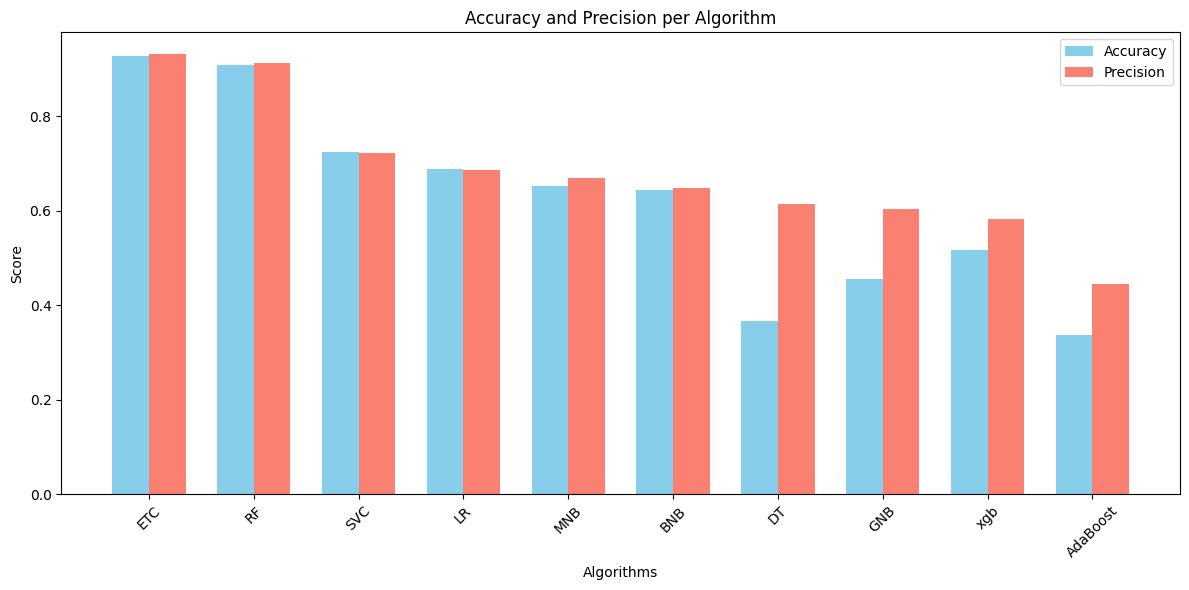

In [66]:
plt.figure(figsize=(12, 6))

# Plot bars for Accuracy and Precision
bar_width = 0.35
indices = range(len(performance_df))

plt.bar(indices, performance_df['Accuracy'], bar_width, label='Accuracy', color='skyblue')
plt.bar([i + bar_width for i in indices], performance_df['Precision'], bar_width, label='Precision', color='salmon')

# Labels and titles
plt.xlabel('Algorithms')
plt.ylabel('Score')
plt.title('Accuracy and Precision per Algorithm')
plt.xticks([i + bar_width / 2 for i in indices], performance_df['Algorithm'], rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

# Applying ensemble classifiers like voting and stacking in hope to increase accuracy and precision.

In [40]:
voting_clf = VotingClassifier(
    estimators=[('etc', etc), ('rfc', rfc)],
    voting='soft'
)

voting_clf.fit(X_train, y_train)

predictions_voting = voting_clf.predict(X_test)

print(f'Voting Classifier Accuracy: {accuracy_score(y_test, predictions_voting)}')
print(classification_report(y_test, predictions_voting))
print(f'Voting Classifier Precision: {precision_score(y_test, predictions_voting, average="macro")}')

Voting Classifier Accuracy: 0.9225291939618342
              precision    recall  f1-score   support

           0       0.95      0.86      0.90      2410
           1       0.92      0.95      0.93      4185
           2       0.95      0.91      0.93      3509
           3       0.89      0.94      0.91      3940

    accuracy                           0.92     14044
   macro avg       0.93      0.92      0.92     14044
weighted avg       0.92      0.92      0.92     14044

Voting Classifier Precision: 0.9273718463923892


In [82]:
base_learners = [
    ('etc', etc)
]

stacking_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(solver='liblinear', penalty='l1')
)

stacking_clf.fit(X_train, y_train)

predictions_stacking = stacking_clf.predict(X_test)
print(f'Stacking Classifier Accuracy: {accuracy_score(y_test, predictions_stacking)}')
print(classification_report(y_test, predictions_stacking))
print(f'Stacking Classifier Precision: {precision_score(y_test, predictions_stacking, average="macro")}')

C:\Users\sahil\anaconda3\envs\py310\lib\site-packages\sklearn\svm\_base.py:1243: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Stacking Classifier Accuracy: 0.9290088293933352
              precision    recall  f1-score   support

           0       0.94      0.90      0.92      2410
           1       0.94      0.94      0.94      4185
           2       0.95      0.93      0.94      3509
           3       0.90      0.94      0.92      3940

    accuracy                           0.93     14044
   macro avg       0.93      0.93      0.93     14044
weighted avg       0.93      0.93      0.93     14044

Stacking Classifier Precision: 0.9303779640830212


In [89]:
voting_stacking_df = pd.DataFrame({
    'Algorithm': ['Voting', 'Stacking'],
    'Accuracy': [accuracy_score(y_test, predictions_voting), accuracy_score(y_test, predictions_stacking)],
    'Precision': [precision_score(y_test, predictions_voting, average="macro"), precision_score(y_test, predictions_stacking, average="macro")]
    #'Accuracy': [0.9225291939618342, 0.9290088293933352],
    #'Precision': [0.9273718463923892, 0.9303779640830212]
})

# Append this DataFrame to the existing performance_df
performance_df = pd.concat([performance_df, voting_stacking_df], ignore_index=True)

performance_df = performance_df.sort_values('Precision', ascending=False)
print(performance_df)

   Algorithm  Accuracy  Precision
0        ETC  0.926873   0.930660
11  Stacking  0.929009   0.930378
10    Voting  0.922529   0.927372
1         RF  0.907434   0.913089
2        SVC  0.724722   0.722012
3         LR  0.687625   0.685022
4        MNB  0.652093   0.668734
5        BNB  0.643406   0.648468
6         DT  0.365708   0.613872
7        GNB  0.456067   0.604181
8        xgb  0.517659   0.581763
9   AdaBoost  0.337297   0.443791


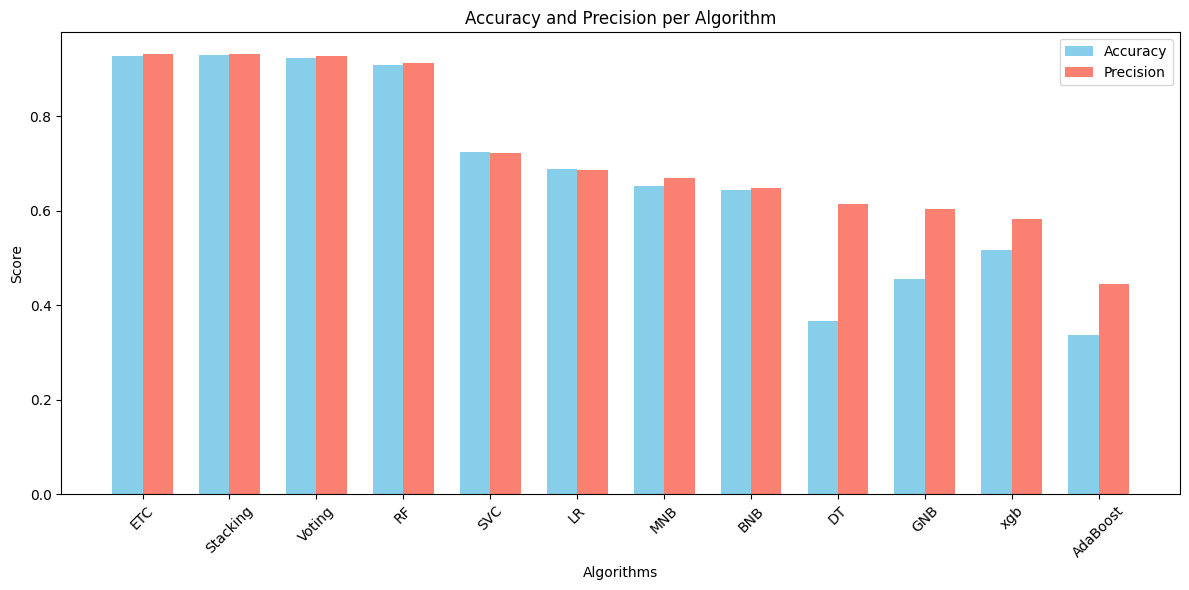

In [90]:
plt.figure(figsize=(12, 6))

# Plot bars for Accuracy and Precision
bar_width = 0.35
indices = range(len(performance_df))

plt.bar(indices, performance_df['Accuracy'], bar_width, label='Accuracy', color='skyblue')
plt.bar([i + bar_width for i in indices], performance_df['Precision'], bar_width, label='Precision', color='salmon')

# Labels and titles
plt.xlabel('Algorithms')
plt.ylabel('Score')
plt.title('Accuracy and Precision per Algorithm')
plt.xticks([i + bar_width / 2 for i in indices], performance_df['Algorithm'], rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

In [96]:
final_model = ExtraTreesClassifier(n_estimators=100, random_state=2, n_jobs=-1)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.87      0.91      2410
           1       0.93      0.95      0.94      4185
           2       0.95      0.92      0.94      3509
           3       0.89      0.94      0.92      3940

    accuracy                           0.93     14044
   macro avg       0.93      0.92      0.93     14044
weighted avg       0.93      0.93      0.93     14044



In [100]:
'''
Using a stacking classifier is best because it leverages the strengths of multiple diverse base models, often resulting in superior predictive performance and robustness compared to any single model.
'''

'\nUsing a stacking classifier is best because it leverages the strengths of multiple diverse base models, often resulting in superior predictive performance and robustness compared to any single model.\n'

# Importing the model

In [102]:
import joblib

# Save the TF-IDF Vectorizer
joblib.dump(tfidf, 'tfidf.joblib')
# Save the stacking model
joblib.dump(stacking_clf, 'model.joblib')

print("Files saved successfully")

Files saved successfully


In [104]:
loaded_model = joblib.load('model.joblib')  # Load the model
loaded_vectorizer = joblib.load('tfidf.joblib') # Load the vectorizer

# Test loaded model by making predictions
y_pred_loaded = loaded_model.predict(X_test)

print("Accuracy after loading:", accuracy_score(y_test, y_pred_loaded))
print("Precision after loading:", precision_score(y_test, y_pred_loaded, average = 'macro'))
print(classification_report(y_test, y_pred_loaded))

Accuracy after loading: 0.9290088293933352
Precision after loading: 0.9303779640830212
              precision    recall  f1-score   support

           0       0.94      0.90      0.92      2410
           1       0.94      0.94      0.94      4185
           2       0.95      0.93      0.94      3509
           3       0.90      0.94      0.92      3940

    accuracy                           0.93     14044
   macro avg       0.93      0.93      0.93     14044
weighted avg       0.93      0.93      0.93     14044



In [106]:
print(df['text'][35000])
print(df['sentiment'][35000])

Just earned my Know the Basics with advice on the Microsoft Educator Center! Teachers can print off free PD courses too..  education.microsoft.com/en-us/course/b… عبر @MicrosoftEDU.. 500
Neutral


In [108]:
def prediction(tweet):
    preprocessed_tweet = transform_text(tweet)
    print(f'Processed tweet: {preprocessed_tweet}')
    tweet_list = [preprocessed_tweet]
    tweet_vector = loaded_vectorizer.transform(tweet_list)
    prediction = loaded_model.predict(tweet_vector)[0]
    return prediction



prediction = prediction(df['text'][35000])

if prediction == 0:
    print(f"Irrelevant tweet and actual sentiment is {df['sentiment'][35000]} ")
elif prediction == 1:
    print(f"Negative tweet and actual sentiment is {df['sentiment'][35000]} ")
elif prediction == 2:
    print(f"Neutral tweet and actual sentiment is {df['sentiment'][35000]} ")
else:
    print(f"Positive tweet and actual sentiment is {df['sentiment'][35000]} ")

Processed tweet: earn know basic advic microsoft educ center teacher print free pd cours educ microsoft com en us cours b عبر microsoftedu 500
Neutral tweet and actual sentiment is Neutral 
